### STEP 0-1: SELECTION OF A COMPANY AND DATA PREPARATION

In [2]:
#first of all, import the needed libraries
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
import yfinance as yf

#load the dataset and create a copy to work on, selecting only the relevant columns
df_raw=pd.read_csv("data/Symbol_Info_extended.csv")
df=df_raw[["symbol","company_name","sector","industry","country",
          "market_cap","return_on_assets","return_on_equity",
          "profit_margins","pe_trailing","price_to_book","revenue_growth",
          "debt_to_equity","free_cashflow"]].copy()

df.head(10)


,symbol,company_name,sector,industry,country,market_cap,return_on_assets,return_on_equity,profit_margins,pe_trailing,price_to_book,revenue_growth,debt_to_equity,free_cashflow
0,A,"Agilent Technologies, Inc.",Healthcare,Diagnostics & Research,United States,3.248796e+10,0.08533,0.19946,0.18259,25.377481,4.704534,0.070,51.390,8.558750e+08
1,AA,Alcoa Corporation,Basic Materials,Aluminum,United States,1.883646e+10,0.04241,0.15427,0.08171,18.302563,2.759500,-0.052,37.019,1.087375e+09
2,AAL,American Airlines Group Inc.,Industrials,Airlines,United States,9.160185e+09,0.01846,NaN,0.00361,44.677420,-2.246918,0.108,NaN,8.611250e+08
3,AAMI,Acadian Asset Management Inc.,Financial Services,Asset Management,United States,2.550323e+09,0.12664,1.11725,0.13785,30.459576,32.910347,0.393,346.579,1.208000e+08
4,AAOI,"Applied Optoelectronics, Inc.",Technology,Communication Equipment,United States,1.456326e+10,-0.03317,-0.06126,-0.08548,NaN,12.958943,0.514,25.356,-4.455833e+08
5,AAON,"AAON, Inc.",Industrials,Building Products & Equipment,United States,1.102532e+10,0.06873,0.13499,0.07305,95.461000,11.793570,0.543,47.455,-2.151344e+08
6,AAP,"Advance Auto Parts, Inc.",Consumer Cyclical,Auto Parts,United States,3.496078e+09,0.01768,0.03084,0.00510,51.741074,1.581907,0.012,255.310,-2.255000e+08
7,AAPL,Apple Inc.,Technology,Consumer Electronics,United States,4.535749e+12,0.26229,1.41471,0.27152,37.432728,42.537190,0.166,79.548,1.010907e+11
8,AAT,"American Assets Trust, Inc.",Real Estate,REIT - Diversified,United States,1.767101e+09,0.02126,0.02157,0.04206,75.933334,1.230420,0.018,159.055,8.720862e+07
9,ABBV,AbbVie Inc.,Healthcare,Drug Manufacturers - General,United States,3.810972e+11,0.10032,NaN,0.05786,105.219510,-57.260418,0.124,NaN,2.081162e+10


In [3]:
#DATA PREPARATION

#replace infinite values with NaN
df=df.replace([np.inf,-np.inf], np.nan)

#exclude companies with market_cap<=0
df=df[df["market_cap"]>0]

#set values of pe_trailing and price_to_book<=0 to NaN
df.loc[df["pe_trailing"]<=0,"pe_trailing"]=np.nan
df.loc[df["price_to_book"]<=0,"price_to_book"]=np.nan

#conversion of large dollar values into billions for readibility
df["market_cap_b"]=df["market_cap"]/1e9
df["free_cashflow_b"]=df["free_cashflow"]/1e9

#conversion of decimal ratios into percentages for readibility
df["return_on_assets_p"]=df["return_on_assets"]*100
df["return_on_equity_p"]=df["return_on_equity"]*100
df["profit_margins_p"]=df["profit_margins"]*100
df["revenue_growth_p"]=df["revenue_growth"]*100
#since debt_to_equity is already expressed as a percentage, I will only give an appropriate name to its column
df["debt_to_equity_p"]=df["debt_to_equity"]


df.head(10)

,symbol,company_name,sector,industry,country,market_cap,return_on_assets,return_on_equity,profit_margins,pe_trailing,...,revenue_growth,debt_to_equity,free_cashflow,market_cap_b,free_cashflow_b,return_on_assets_p,return_on_equity_p,profit_margins_p,revenue_growth_p,debt_to_equity_p
0,A,"Agilent Technologies, Inc.",Healthcare,Diagnostics & Research,United States,3.248796e+10,0.08533,0.19946,0.18259,25.377481,...,0.070,51.390,8.558750e+08,32.487961,0.855875,8.533000,19.945998,18.259001,7.0,51.390
1,AA,Alcoa Corporation,Basic Materials,Aluminum,United States,1.883646e+10,0.04241,0.15427,0.08171,18.302563,...,-0.052,37.019,1.087375e+09,18.836457,1.087375,4.241000,15.427000,8.171000,-5.2,37.019
2,AAL,American Airlines Group Inc.,Industrials,Airlines,United States,9.160185e+09,0.01846,NaN,0.00361,44.677420,...,0.108,NaN,8.611250e+08,9.160185,0.861125,1.846000,NaN,0.361000,10.8,NaN
3,AAMI,Acadian Asset Management Inc.,Financial Services,Asset Management,United States,2.550323e+09,0.12664,1.11725,0.13785,30.459576,...,0.393,346.579,1.208000e+08,2.550323,0.120800,12.663999,111.725000,13.785000,39.3,346.579
4,AAOI,"Applied Optoelectronics, Inc.",Technology,Communication Equipment,United States,1.456326e+10,-0.03317,-0.06126,-0.08548,NaN,...,0.514,25.356,-4.455833e+08,14.563260,-0.445583,-3.317000,-6.126000,-8.548001,51.4,25.356
5,AAON,"AAON, Inc.",Industrials,Building Products & Equipment,United States,1.102532e+10,0.06873,0.13499,0.07305,95.461000,...,0.543,47.455,-2.151344e+08,11.025317,-0.215134,6.873000,13.498999,7.305000,54.3,47.455
6,AAP,"Advance Auto Parts, Inc.",Consumer Cyclical,Auto Parts,United States,3.496078e+09,0.01768,0.03084,0.00510,51.741074,...,0.012,255.310,-2.255000e+08,3.496078,-0.225500,1.768000,3.084000,0.510000,1.2,255.310
7,AAPL,Apple Inc.,Technology,Consumer Electronics,United States,4.535749e+12,0.26229,1.41471,0.27152,37.432728,...,0.166,79.548,1.010907e+11,4535.749181,101.090746,26.229000,141.470990,27.152002,16.6,79.548
8,AAT,"American Assets Trust, Inc.",Real Estate,REIT - Diversified,United States,1.767101e+09,0.02126,0.02157,0.04206,75.933334,...,0.018,159.055,8.720862e+07,1.767101,0.087209,2.126000,2.157000,4.206000,1.8,159.055
9,ABBV,AbbVie Inc.,Healthcare,Drug Manufacturers - General,United States,3.810972e+11,0.10032,NaN,0.05786,105.219510,...,0.124,NaN,2.081162e+10,381.097214,20.811624,10.032000,NaN,5.786000,12.4,NaN


In [5]:
#choosing the company

#creating a dateframe with countries belonging only to Asia
df_asia=df[df["country"].isin(["China","Taiwan","Singapore","South Korea",
                               "Hong Kong"])]

#sorting them by market capitalization
df_asia=df_asia.sort_values(by="market_cap",ascending=False)

#setting the chosen company with its chosen symbol
chosen=df_asia[df_asia["symbol"]=="SE"]
chosen_symbol=chosen["symbol"].iloc[0]


Among those asian companies I choose company SE because it has one of the biggest market capitalization, so it seems big enough but still not dominant. Also it has one of the biggest values for revenue_growth, implying that it has one of the biggest growth rates (and it is to be expected since this company works for internet retail services). Intermediate values for both ROA and ROE,  intermediate profit margins and a strong pe_trailing when combined to all the information from before confirm that the company is in a phase of strong growth. Also, debt to equity is small enough and, even though the enterprise is in a growth phase it shows big, positive cashflows, confirming the strong structure of it. In my opinion, choosing a company like SE is the perfect choice, since it is big and stable enough but not too dominant, so comparisons among peers can be highly informative.

### STEP 2: BUILD PEER GROUPS

In [7]:
#building peer groups

#SAME INDUSTRY

#selecting the same industry of the chosen company
industry=chosen["industry"].iloc[0]
#selecting only the companies whose industry is the same as the one of the chosen company
industry_peer=df[df["industry"]==industry].copy()
#sorting those companies by market capitalization and selecting only the top10
industry_peer=industry_peer.sort_values(by="market_cap",ascending=False).head(10)

#if the selected company is not yet in the top10 then we add it
if chosen_symbol not in industry_peer["symbol"].values:
    industry_peer=pd.concat([industry_peer,chosen])





#SAME GEOGRAPHIC GROUP

#using the asian companies dataframe, sorting it by market capitalization and considering only the top10 companies
geo_peer=df_asia.copy()
geo_peer=geo_peer.sort_values(by="market_cap",ascending=False).head(10)

#if the selected company is not yet in the top10 we need to include it
if chosen_symbol not in geo_peer["symbol"].values:
    geo_peer=pd.concat([geo_peer,chosen])



#SIMILAR MARKET CAPITALIZATION

#getting the market capitalization of the chosen company
chosen_mc=chosen["market_cap"].iloc[0]

mc_peer=df.copy()
#creating a column where the absolute difference of market capitalization is computed
mc_peer["mc_distance"]=(mc_peer["market_cap"]-chosen_mc).abs()
#sorting the values by absolute difference in market capitalization and getting only the top10
mc_peer=mc_peer.sort_values(by="mc_distance",ascending=True).head(10)
#no need to check if the selected company is in this dataframe, because it for sure will, since
#the difference in market capitalization between the selected company and itself is going to
#be 0 (one of the smallest values for sure)


### STEP 3: Is the company profitable?

In [8]:
#creating a function to be used multiple times with different peer groups and metrics
def plot_metric1(group, metric, title):

    #getting the data from the peer group of interest and removing eventual observations with na in the metrics of interest
    data = group.copy()
    data = data.dropna(subset=[metric])

    #using the symbol if company name is not available
    labels = np.where(data["company_name"].isna(),data["symbol"],data["company_name"])

    #colors of the bars referring to the peers
    colors = ["#B0B7C3"] * len(data)

    #taking the symbol of the chosen company
    selected_symbol = chosen["symbol"].iloc[0]

    #if the symbol is the one of the chosen company, then that bar's color will be different, else grey will be used
    for i, symbol in enumerate(data["symbol"]):
        if symbol == selected_symbol:
            colors[i] = "#2A9D8F"


    #computing the median referred to that particular metric
    median=data[metric].median()

    #creating the image for the plot
    fig,ax= plt.subplots(figsize=(14,5))

    #creating the horizontal boxplot
    bars=ax.barh(labels,data[metric],color=colors)
    
    #since the ROE and profit margins can be negative, we add the zero baseline
    ax.axvline(0, color="black", linewidth=1)
    
    #adding the line for the median
    ax.axvline(median, linewidth=2, color="#1F4E79", linestyle=":", label=f"Median: {median:.2f}%")

    #adding the labels for the numbers for each bar in the graph
    ax.bar_label(bars,fmt="%.2f%%",padding=3,fontsize=9)

    #adding a vertical grid in transparence
    ax.grid(axis='x',alpha=0.35)
    #setting the title of the graph
    ax.set_title(title)
    #setting x and y labels
    ax.set_xlabel(metric + " (%)")
    ax.set_ylabel("Companies")
    #adding a legend
    ax.legend()
    #removing spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


    #to improve readibility, add a margin on the left and right sides of the chart
    x_min, x_max = ax.get_xlim()
    buffer = (x_max - x_min) * 0.01  
    ax.set_xlim(x_min - buffer, x_max + buffer)

    #using a tight layout to improve readibility and showing the final plot
    plt.tight_layout()
    plt.show()

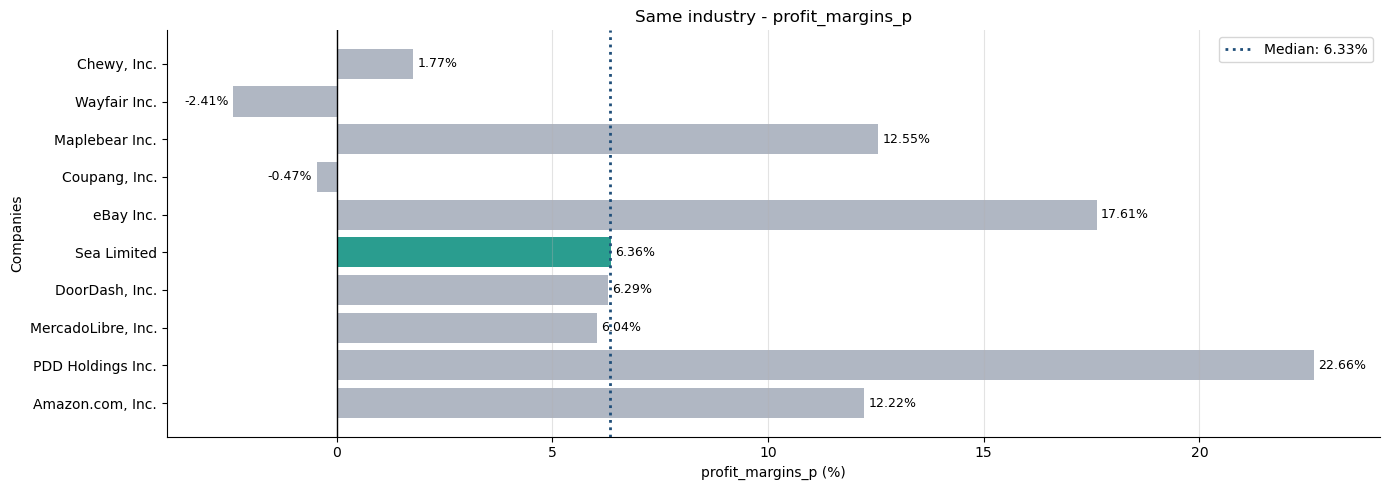

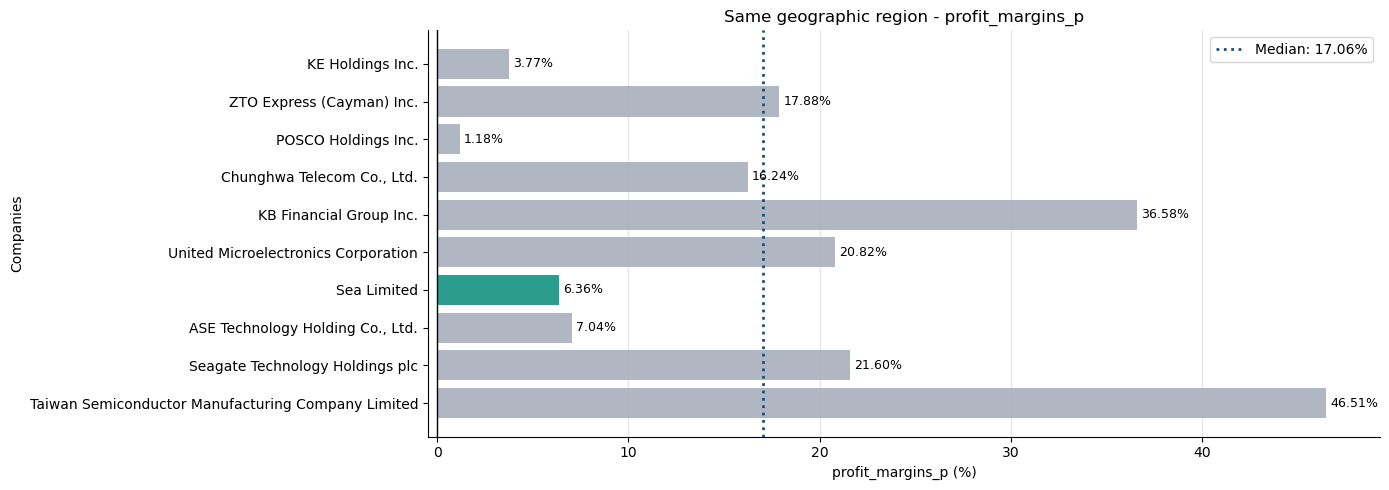

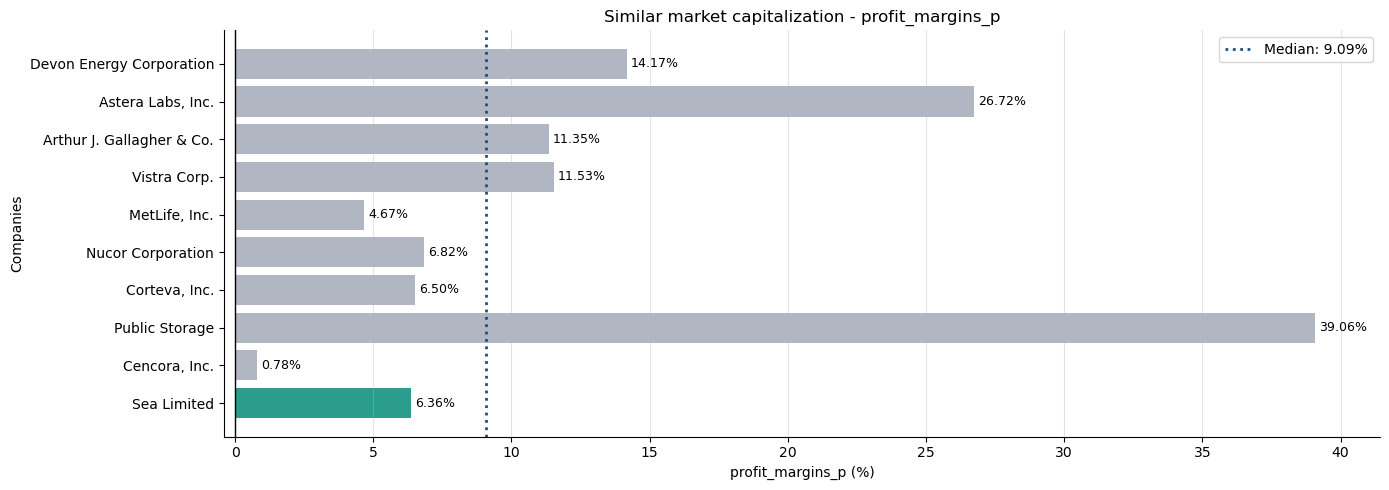

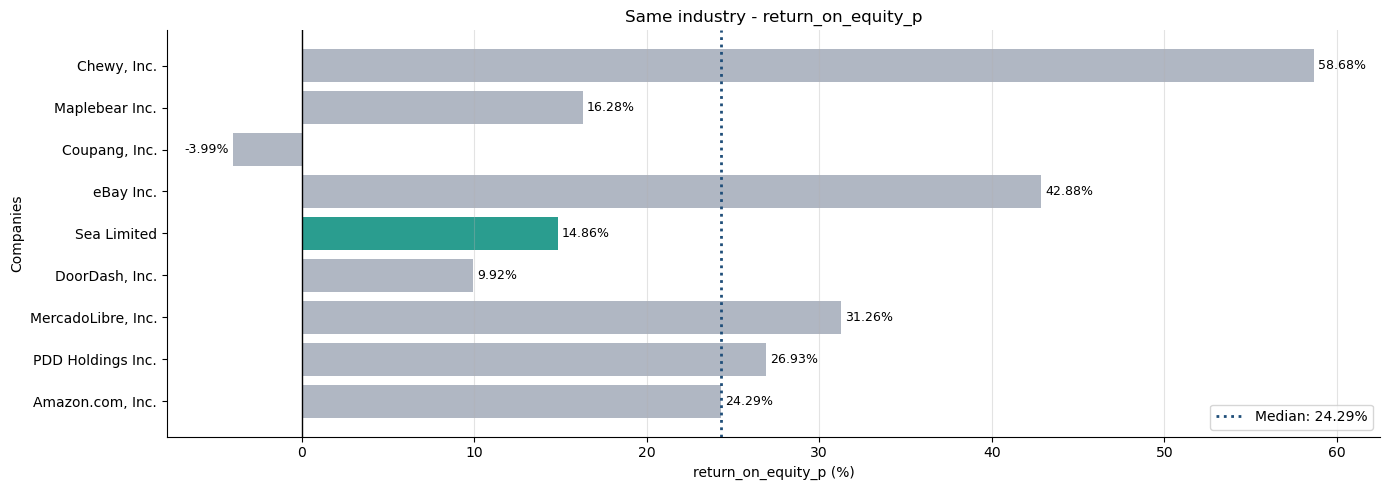

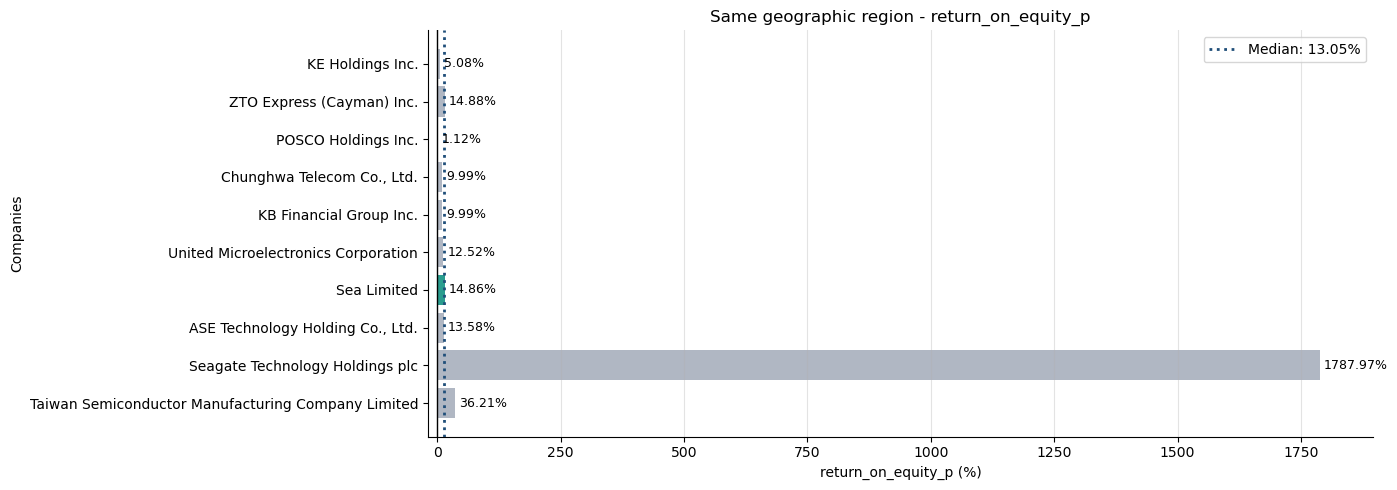

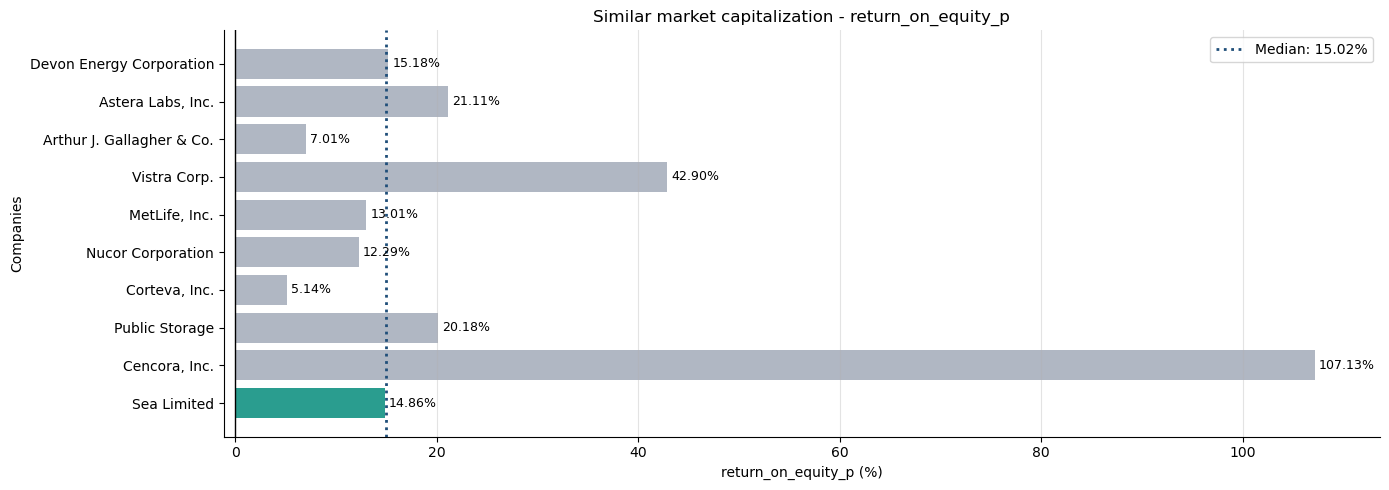

In [9]:
#defining the metrics of interest
metrics = ["profit_margins_p", "return_on_equity_p"]

#for each peer group and metric of interest, creating the graph
for metric in metrics:

    plot_metric1(industry_peer, metric, f"Same industry - {metric}")
    plot_metric1(geo_peer, metric, f"Same geographic region - {metric}")
    plot_metric1(mc_peer, metric, f"Similar market capitalization - {metric}")

As it is possible to see from the graphs above, the selected company is never significantly above the median of its peer groups: in some cases it is below the median, while in other it is perfectly in line with it. 

In the first graph, profit margins of the companies were compared on an industry basis: the profit margins of the selected company are broadly in line, and perhaps a little above, the industry median, suggesting that, in this case, the company is directly comparable to its industry peers.

In the second graph, profit margins of the companies were compared on a geographical basis: the profit margin of the selected company is well below the median, implying that the selected company is less profitable than the median Asian company included in the top 10. In fact, from the graph it is possible to notice how the top-performing companies significantly skew the distribution, while the selected company lags behind. This suggests that, despite working in a geographical context where many peers achieve stronger margins, some companies may still face lower pricing power or less favorable competitive conditions.

In the third graph, profit margins of the companies were compared on a market-capitalization basis: the profit margins of the selected company, when compared to other companies with similar market capitalization, are well below the median, suggesting that SE company is less effective in converting revenue into profit that other firms of similar size.

In this context, what is interesting to point out is the following: on one hand, the company seems to be performing well in terms of profit margin if compared to other companies working in the same industry; on the other hand, when profit margins are compared in the contexts of geographical region and similar market capitalization, the company seems to be underperforming. This highlights that the company's profitability challenges are not driven by industry-specific dynamics, but are rether related to regional competitive pressures and potential inefficiencies in scaling its operations compared to peers of similar size.

In the fourth graph, ROE of the companies were compared on an industry basis: the ROE of the selected company is well below the median, implying that it generates lower returns for shareholders than the average company in the industry. This may reflect a less efficient use of equity capital or a more conservative financial structure.

In the fifth graph, ROE of the companies were compared on a geographical basis: the ROE of the selected company is perfectly in line with the median, suggesting its ability to generate returns for shareholders in the Asian context.

In the sixth graph, ROE of the companies were compared on a market-capitalization basis: the ROE of the selected company, when compared to other companies with similar market capitalization, is in line with the median, indicating that the returns for the shareholders are comparable with the ones made by firms of similar scale.

In this case, the selected company seems to work well in terms of ROE in the contexts of geographical region and similar market capitalization; however, this evidence is not confirmed when referring to other companies operating in the same industry. This evidence suggests that while the company aligns with regional standards and scale-related expectations in terms of shareholder returns, it underperforms against global industry banchmarks.

### STEP 4: Is the company expensive or cheap?

In [10]:
#defining a function to use with different peer groups and metrics
def plot_metric2(group, metric, title):

    #selecting data from the peer group of interest
    data = group.copy()

    #treat values <=0 as missing and drop observations with eventual na
    data.loc[data[metric]<=0,metric]=np.nan
    data=data.dropna(subset=[metric])

    #sort in ascending order
    data=data.sort_values(metric)

    #using the symbol if company name is not available
    labels = np.where(data["company_name"].isna(),data["symbol"],data["company_name"])

    #colors of the bars referring to the peers
    colors = ["#B0B7C3"] * len(data)

    #taking the symbol of the chosen company
    selected_symbol = chosen["symbol"].iloc[0]

    #if the symbol is the one of the chosen company, then that bar's color will be different, else grey will be used
    for i, symbol in enumerate(data["symbol"]):
        if symbol == selected_symbol:
            colors[i] = "#2A9D8F"


    #computing the median referred to that particular metric
    median=data[metric].median()

    #creating the image for the plot
    fig,ax= plt.subplots(figsize=(14,5))

    #creating the horizontal boxplot
    bars=ax.barh(labels,data[metric],color=colors)
    
    
    #adding median line for better interpretation
    ax.axvline(median, linewidth=2, color="#1F4E79", linestyle=":", label=f"Median: {median:.2f}")

    #adding the labels for the numbers for each bar in the graph
    ax.bar_label(bars,fmt="%.2f",padding=3,fontsize=9)

    #adding a vertical grid in transparence
    ax.grid(axis='x',alpha=0.35)
    #setting the title of the graph
    ax.set_title(title)
    #setting x and y labels
    ax.set_xlabel(metric)
    ax.set_ylabel("Companies")
    #adding a legend
    ax.legend()
    #removing spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    #to improve readibility, add a margin on the left and right sides of the chart
    x_min, x_max = ax.get_xlim()
    buffer = (x_max - x_min) * 0.01  
    ax.set_xlim(x_min - buffer, x_max + buffer)

    #using a tight layout to improve readibility and showing the final plot
    plt.tight_layout()
    plt.show()

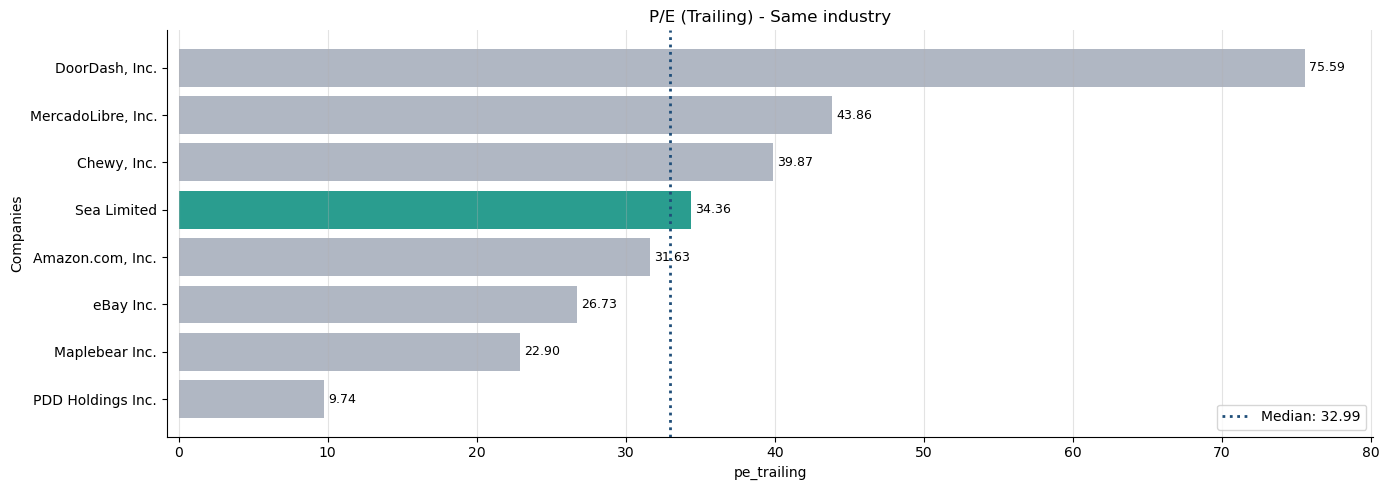

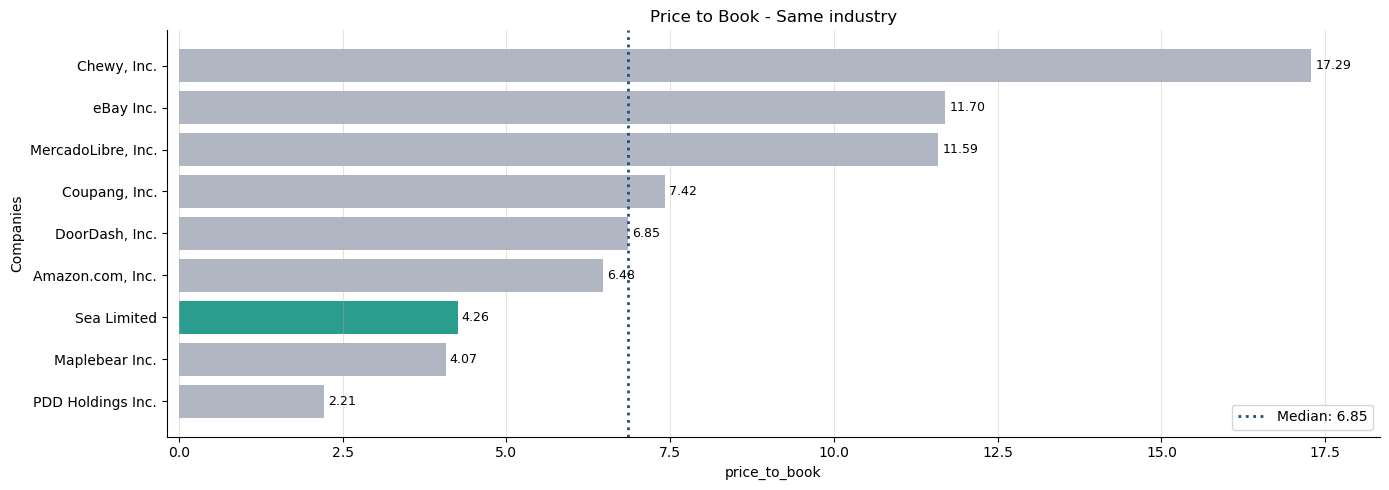

In [11]:
#for each metric of interest creating the graph
plot_metric2(industry_peer, "pe_trailing", "P/E (Trailing) - Same industry")
plot_metric2(industry_peer, "price_to_book", "Price to Book - Same industry")

Based on the two metrics used, this is what is possible to say about the chosen company:
- the selected company has a P/E trailing ratio which sits slightly above the industry median. This indicates that from an earnings perspective the company is slightly expensive if compared to some peers, but significantly cheaper than other giants such as DoorDash;
- on the other hand, the price to book ratio for the selected company is well below the industry median.

All in all, the selected company appears to be fairly valued: while the price to book is on the lower side, the P/E trailing is above the median for the industry. The higher P/E trailing implies that the market is pricing a premium for either current earning of the company or for future expectations in earnings' growth; however, a lower value for the price to book suggests that the company has a solid asset base and isn't inflated by highly speculative assets.

### STEP 5: Is the company growing?

In [12]:
#defining a function to use with different peer groups
def plot_metric3(group,title,cap=200):

    #selecting data from the peer group of interest
    data = group.copy()

    #deleting observations with na and treating extreme outliers by applying a cap
    data=data.dropna(subset=["revenue_growth_p"])

    data["revenue_growth_cap"]=data["revenue_growth_p"].clip(lower=-cap,upper=cap)


    #sort in ascending order
    data=data.sort_values("revenue_growth_cap")

    #using the symbol if company name is not available
    labels = np.where(data["company_name"].isna(),data["symbol"],data["company_name"])

    #colors of the bars referring to the peers
    colors = ["#B0B7C3"] * len(data)

    #taking the symbol of the chosen company
    selected_symbol = chosen["symbol"].iloc[0]

    #if the symbol is the one of the chosen company, then that bar's color will be different, else grey will be used
    for i, symbol in enumerate(data["symbol"]):
        if symbol == selected_symbol:
            colors[i] = "#2A9D8F"


    #computing the median referred to that particular metric
    median=data["revenue_growth_cap"].median()


    #creating the image for the plot
    fig,ax= plt.subplots(figsize=(14,5))

    #creating the horizontal boxplot
    bars=ax.barh(labels,data["revenue_growth_cap"],color=colors)


    #adding a zero line since revenue growth can be negative
    ax.axvline(0,color="black",linewidth=1)
    
    
    #adding median line for better interpretation
    ax.axvline(median, linewidth=2, color="#1F4E79", linestyle=":", label=f"Median: {median:.2f}%")

    #adding the labels for the numbers for each bar in the graph
    ax.bar_label(bars,fmt="%.2f%%",padding=3,fontsize=9)

    #adding a vertical grid in transparence
    ax.grid(axis='x',alpha=0.35)
    #setting the title of the graph
    ax.set_title(title)
    #setting x and y labels
    ax.set_xlabel("Revenue growth (%)")
    ax.set_ylabel("Companies")
    #adding a legend
    ax.legend()
    #removing spines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    #to improve readibility, add a margin on the left and right sides of the chart
    x_min, x_max = ax.get_xlim()
    buffer = (x_max - x_min) * 0.025
    ax.set_xlim(x_min - buffer, x_max + buffer)

    #using a tight layout to improve readibility and showing the final plot
    plt.tight_layout()
    plt.show()

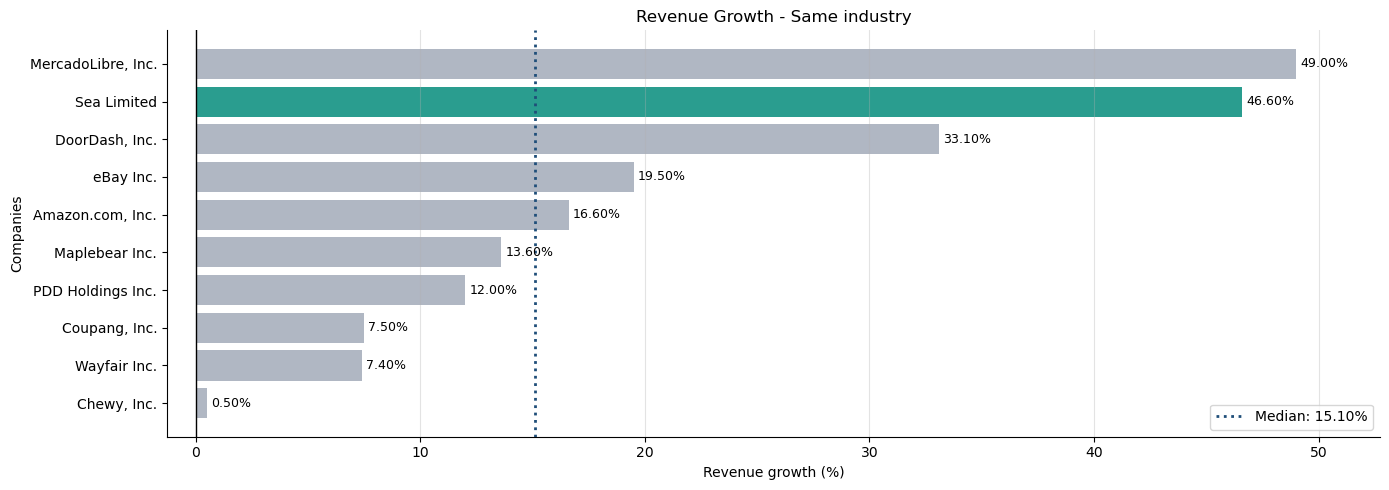

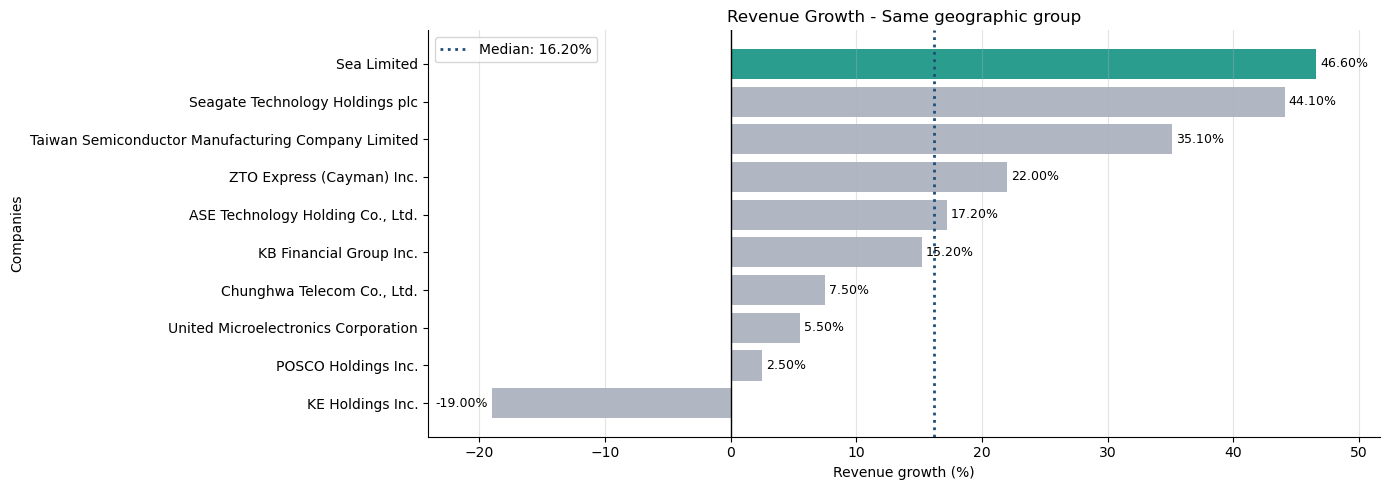

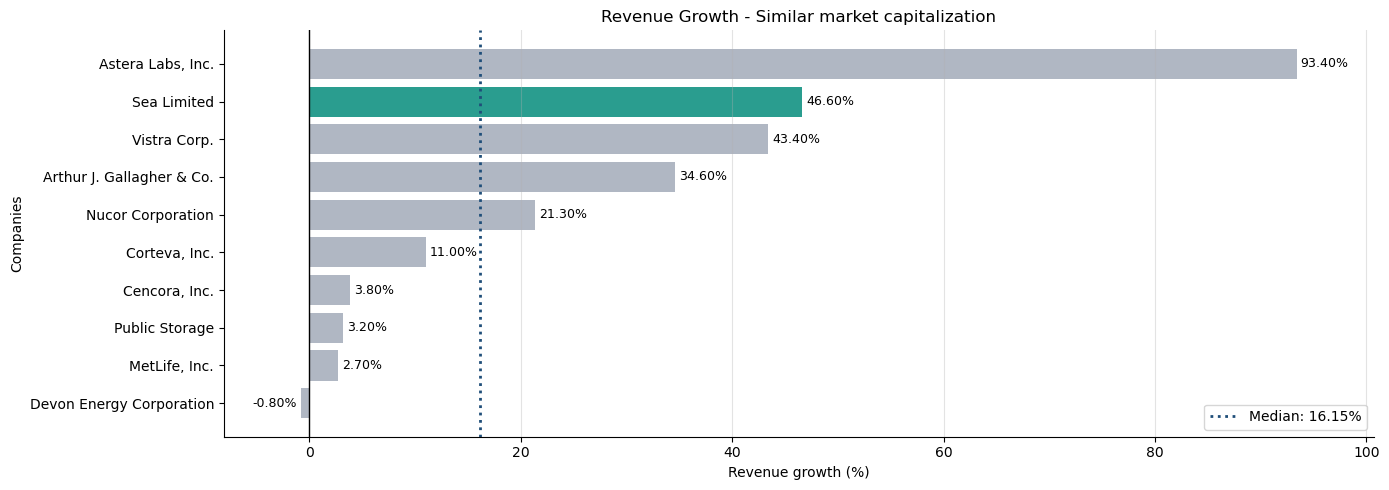

In [13]:
#plotting the graph for each peer group of interest 
plot_metric3(industry_peer, "Revenue Growth - Same industry")
plot_metric3(geo_peer, "Revenue Growth - Same geographic group")
plot_metric3(mc_peer, "Revenue Growth - Similar market capitalization")

Based on the charts, the chosen company is growing in a positive way, showing robust acceleration across all the peer groups and outpacing strong players, such as Amazon, and always sitting near the top of the chart.

This explosive growth explains the seemingly contradictory evaluation metrics from step 4: since the chosen company is expanding its revenue at a fast pace, investors are highly willing to pay a premium, therefore incresing the P/E trailing; on the other hand, a lower price to book ratio, compared with a revenue growth of this kind, suggests that the company is scaling its revenue streams and the stock market has not yet hyper-infleted its evaluation.

 Overall, this particular combination represents an investment opportunity.

### STEP 6: Is the company financially stable?

In [14]:
#defining a function to use with different peer groups and metrics
def plot_metric4(group,metric,title,better_higher=True):

    #selecting data from the peer group of interest and dropping eventual observations with na
    data = group.copy()
    data = data.dropna(subset=[metric])

    #since mebt to equity had large outliers we need to apply a cap
    if metric=="debt_to_equity_p":
        data[metric]=data[metric].clip(upper=1000)

    #sorting the values depending on the nature of the metric, using the variable better_higher
    data = data.sort_values(metric,ascending=not better_higher)

    #using the symbol if company name is not available
    labels = np.where(data["company_name"].isna(),data["symbol"],data["company_name"])

    #colors of the bars referring to the peers
    colors = ["#B0B7C3"] * len(data)


    #taking the symbol of the chosen company
    selected_symbol = chosen["symbol"].iloc[0]

    #if the symbol is the one of the chosen company, then that bar's color will be different, else grey will be used
    for i, symbol in enumerate(data["symbol"]):
        if symbol == selected_symbol:
            colors[i] = "#2A9D8F"


    #creating the image for the plot
    fig, ax = plt.subplots(figsize=(14, 5))

    #creating the horizontal boxplot
    bars = ax.barh(labels, data[metric], color=colors)

    #adding a zero line since free cashflow can be negative
    ax.axvline(0, color="black", linewidth=1)

    #computing the median referred to that particular metric and setting a different format, based on the nature of data
    median = data[metric].median()
    if metric=="debt_to_equity_p":
        #using % for debt to equity
        ax.axvline(median,color="#1F4E79",linestyle=":",linewidth=2,label=f"Median: {median:.2f}%")
    elif metric=="free_cashflow_b":
        #using USD B for cashflows
        ax.axvline(median,color="#1F4E79",linestyle=":",linewidth=2,label=f"Median: {median:.2f}B$")

    
    #adding the labels for the numbers for each bar in the graph and giving them a specific format, depending on the nature of data
    if metric=="debt_to_equity_p":
        ax.bar_label(bars, fmt="%.2f%%", padding=3)
    elif metric=="free_cashflow_b":
        ax.bar_label(bars, fmt="%.2f B$", padding=3)
    

    #setting the title of the graph
    ax.set_title(title)
    #setting y label
    ax.set_ylabel("Companies")
    #setting x label with the unit of measure of reference
    if metric=="debt_to_equity_p":
        # % for debt to equity
        xlabel="Debt to equity (%)"
    elif metric=="free_cashflow_b":
        # USD B for cashflows
        xlabel="Free cashflow (USD billions)"
    ax.set_xlabel(xlabel)

    #adding a vertical grid in transparence
    ax.grid(axis='x', alpha=0.35)
    #adding a legend
    ax.legend()
    #removing the spines for enhanced readibility
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    #flipping the y axis upside down for better readibility/understanding of the graph
    ax.invert_yaxis()


    #to improve readibility, add a margin on the left and right sides of the chart
    x_min, x_max = ax.get_xlim()
    buffer = (x_max - x_min) * 0.01
    ax.set_xlim(x_min - buffer, x_max + buffer)

    #using a tight layout to improve readibility and showing the final plot
    plt.tight_layout()
    plt.show()

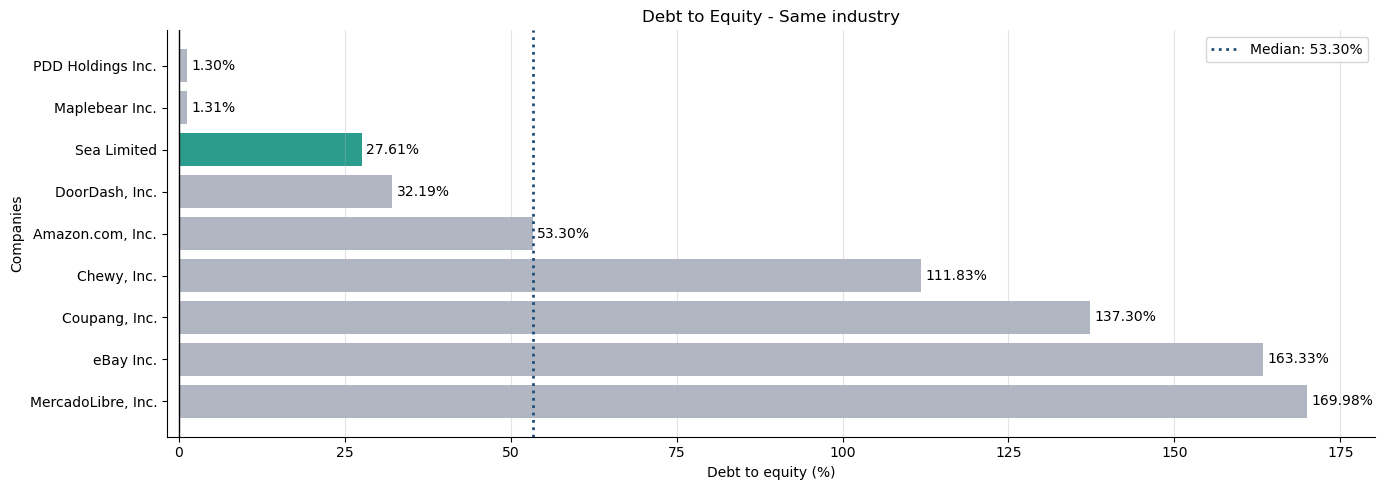

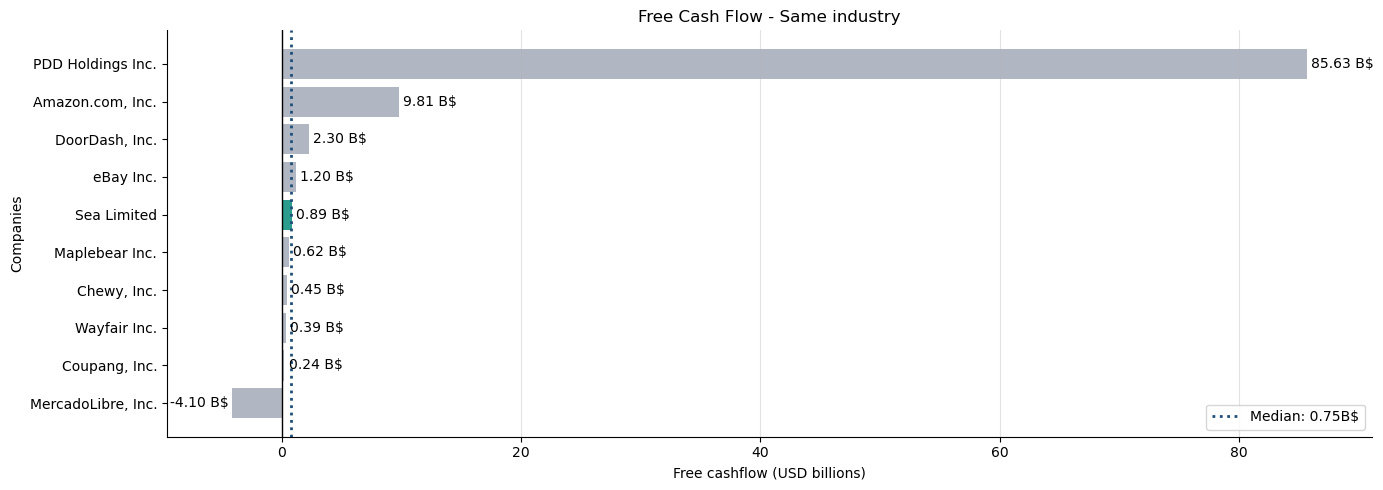

In [15]:
#plotting the graph for each metric of interest
plot_metric4(industry_peer, "debt_to_equity_p", "Debt to Equity - Same industry",better_higher=False)
plot_metric4(industry_peer, "free_cashflow_b", "Free Cash Flow - Same industry")

The selected company does not heavily rely on debt, as the first chart shows (27.61%). Its debt to equity ratio is in fact significantly lower than the peer group median, showing a more conservative structure of the capital with a stronger reliance on equity rather than debt.

This company also generates positive free cashflows (0.89B USD), which are above the peer median of 0.75 B USD, showing that the business is capable of generating cash surplus after accounting for capital expenses.

When all those information are combined it is possible to show that the company has a strong financial profile: it has a lower debt leverage (it makes the company less risky) and it also is capable to generate positive cashflows.

### FINAL SUMMARY

Among these asian companies I chose company SE because it has one of the largest market capitalizations, meaning it is big enough but still not dominant. Also it has one of the highest growth rates and intermediate values for ROA, ROE and profit margins. All this evidence, along with the fact that the company has a high P/E trailing and a low debt to equity, shows that the company is in a phase of strong growth. In short, the company is solid enough and it is getting bigger, but is still not too dominant.   
For this reason, comparisons with peers should yield interesting information.

The chosen company seems to be fairly profitable when compared to its industry peers in terms of profit margins; however, its profitability falls short when evaluated against geographical neighbours and companies of similar scale, highlighting regional pressures and size-related inefficiencies. On the other hand, its ROE meets the expectations within the asian market and among similarly sized companies, but lags behind the industry benchmark. In few words, this contrasting performance suggests that while the firm effectively matches regional standards of shareholder returns, it faces challenges in optimizing asset efficiency and capital structure, compared to its industry competitors.

All in all, the selected company seems to be fairly valued, even though the two metrics used show contrasting results (the P/E trailing is above the median for the industry, whereas the price to book is on the lower side).   
This particular instance might represent either a positive indicator or a negative one, depending on other information.

In particular, according to the following analysis about the growth of the company it is possible to notice that the company is steadily growing, showing a robust acceleration and outpacing most of its peers. 

Moreover, the company has low debt leverage (making it less risky), it is capable of generating positive cash flows and using this surplus to self-sustain its fast-paced growth.   
For this reason, it is now possible to confirm that the higher P/E trailing implies that the market is pricing a premium for either the current earnings of the company or for future expectations of earnings growth; however, a lower value for the price to book suggests that the company has a solid asset base and isn't inflated by highly speculative assets.   
So, it is possible to affirm that the company is solid from a financial point of view.

Metrics unavailable:
-	Return on equity (same industry): 1 company discarded
-	P/E trailing (same industry): 2 companies discarded
-	P/B (same industry): 1 company discarded
-	Debt to equity (same industry): 1 company discarded

As it is possible to notice from this list, a few metrics were unavailable from time to time.   
However, since the selected company did not experience this problem and missing values were removed only for the metrics used in each specific analysis, the final analysis was not heavily affected by these missing values.

